In [39]:
import numpy as np
import maglab
import torch
import torch.nn.functional as F

def remove_background(phase, mask, ):
    # we need to compare the phase shift after removal of low-frequency signal, so we apply a gauss kernel filter on the images.
    gauss_kernel_size = 99
    sigma = maglab.preprocess.compute_sigma(gauss_kernel_size)
    kernel = maglab.preprocess.gaussian_kernel(gauss_kernel_size, sigma)
    kernel_groups = kernel.repeat(8, 1, 1, 1).cuda()
    phase_blurred = F.conv2d(phase, kernel_groups, groups=8, padding=gauss_kernel_size // 2)
    return (mask * (phase - phase_blurred))

def delta_phi(phi1, phi2):
    phi1 = phi1.detach().cpu().numpy()
    phi2 = phi2.detach().cpu().numpy()
    delta = np.sum(abs(phi1 - phi2)) / np.mean(abs(phi1))
    return delta

N = 206
dx = 1.06e-9
geo = maglab.geo.cylider(136, 111)
nx, ny, nz = geo.shape
Ms = 3.84e5
micro = maglab.Micro(nx, ny, nz, dx)

alphas = [0, 28, 44, 50, 54, 58, 61, 65]
phasemapper = maglab.PhaseMapper(N, dx, rotation_padding=N).cuda()
phaseset = maglab.dataset.PhaseSet()

for alpha in alphas:
    phasemap = torch.load(f"..\\recon-scripts\\dataset\\dm3_refin\\refin_3dmask_pm\\phasemap_{alpha}.pth", weights_only=False)
    for item in phasemap:
        data  = item['data'].transpose((1,0))
        mask  = item['mask'].transpose((1,0))
        alpha = -item['alpha']
        phasemap = maglab.dataset.PhaseMap(data=data, mask=mask, alpha=alpha)
    phaseset.load(phasemap)
phaseset.sort()

phase_exeperiments = torch.stack([x.data for x in phaseset]).cuda()
mask = torch.stack([phasemap.mask for phasemap in phaseset]).cuda()
alphas = [x.Euler[0] for x in phaseset]
betas = [x.Euler[1] for x in phaseset]
num_phase = len(phaseset)

ws = list(np.arange(-1.75,2.00,0.25))
energy_values = []
phi_loss_values = []
for w in ws:
    w = 10**w
    base_path = f'..\\recon-scripts\\test_m\\results\\loss0.0e+00_wm{w:.1e}'
    file_path = base_path.format(w=w)
    w1, w2 = 1, w
    try:
        s = micro.load_state(f"{file_path}\\final.pth")
        spin2 = s.get_spin().cuda()
        energy_density = s.get_energy_density(spin2)
        tot_energy = float(torch.sum(energy_density)) * s.dx**3

        phase_pred = torch.stack([phasemapper(spin2, 
                                                alpha=alphas[i], 
                                                beta=betas[i], 
                                                Ms=Ms) 
                                    for i in range(num_phase)])

        phi_loss = delta_phi(remove_background(phase_exeperiments, mask), remove_background(phase_pred, mask))
        phi_loss_value = phi_loss
        
        energy_values.append(tot_energy)
        phi_loss_values.append(phi_loss_value)

    except Exception as e:
        print(f"Error processing w={np.log10(w)}: {e}")
        energy_values.append(np.nan)
        phi_loss_values.append(np.nan)
        
Lm = np.array(energy_values)*1e17
Lphi = np.array(phi_loss_values)

with open(f'loss.txt', 'w') as f:
    f.write("n, Lm, Lphi\n")
    for i, w in enumerate(ws):
        f.write(f"{w}, {Lm[i]}, {Lphi[i]}\n")
print(f"数据已保存到 loss.txt 文件中")


数据已保存到 loss.txt 文件中


已保存文件: loss.csv


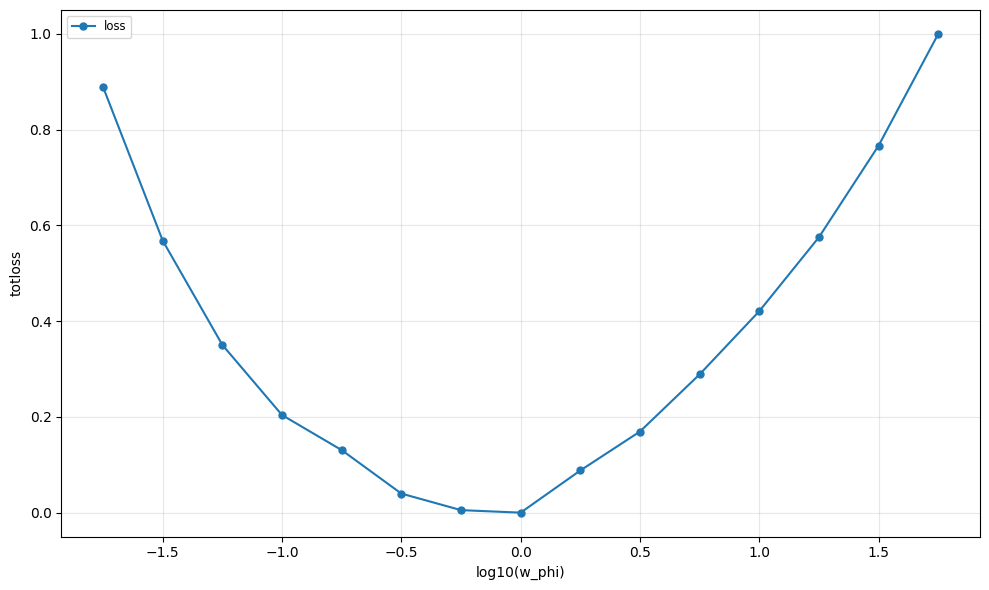

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import csv

files = sorted([fn for fn in os.listdir('.') if fn.endswith('loss.txt')])
if not files:
    print("none '*loss.txt' files")
else:
    all_data = {}
    def normalize(arr):
        mn = np.nanmin(arr)
        mx = np.nanmax(arr)
        if np.isclose(mx, mn):
            return np.zeros_like(arr)
        return (arr - mn) / (mx - mn)

    for fn in files:
        xs = []
        Lm = []
        Lphi = []
        Ltotal_file = []
        with open(fn, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        for line in lines[1:]: 
            parts = line.replace(',', ' ').strip().split()
            if len(parts) < 3:
                continue
            try:
                x = float(parts[0])
                lm = float(parts[1])*1e17
                lphi = float(parts[2])
                ltot = float(parts[3]) if len(parts) > 3 else np.nan
            except Exception:
                continue
            xs.append(x)
            Lm.append(lm)
            Lphi.append(lphi)
            Ltotal_file.append(ltot)

        if len(xs) == 0:
            continue

        xs = np.array(xs)
        Lm = np.array(Lm, dtype=float)
        Lphi = np.array(Lphi, dtype=float)
        Ltotal_file = np.array(Ltotal_file, dtype=float)

        Lm_n = normalize(Lm)
        Lphi_n = normalize(Lphi)
        totloss_calc = normalize(Lm_n + Lphi_n)

        csv_filename = fn.replace('.txt', '.csv')
        with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['x', 'totloss_calc'])
            for i in range(len(xs)):
                writer.writerow([
                    xs[i],
                    totloss_calc[i]
                ])
        print(f"已保存文件: {csv_filename}")

        idx = np.argsort(xs)
        all_data[fn] = {
            'x': xs[idx],
            'totloss_calc': totloss_calc[idx],
            'Ltotal_file': Ltotal_file[idx],
            'Lm': Lm[idx],
            'Lphi': Lphi[idx]
        }

    plt.figure(figsize=(10, 6))
    for fn, dat in all_data.items():
        label = fn.replace('.txt', '')
        plt.plot(dat['x'], dat['totloss_calc'], '-o', label=label, linewidth=1.5, markersize=5)

    plt.xlabel('log10(w_phi)')
    plt.ylabel('totloss')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()
